## **Libraries Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Import**

In [2]:
# Carga del dataset
df = pd.read_csv('Data/data.csv', sep=';')

# Limpiar nombres de columnas (tabs y espacios extra)
df.columns = (
    df.columns
    .str.replace('\t', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
 )

# Renombrar columnas clave
df = df.rename(columns={
    'Target': 'Estado',
    'Curricular units 1st sem (grade)': 'first_semester_grade',
    'Curricular units 2nd sem (grade)': 'second_semester_grade'
})

# Filtrar: solo Dropout y Enrolled (excluir Graduate)
df = df[df['Estado'] != 'Graduate'].copy()

# Crear variable target de clasificación: abandona (0=Enrolled, 1=Dropout)
df['abandona'] = df['Estado'].map({'Dropout': 1, 'Enrolled': 0})

# Variable target de regresión: usamos second_semester_grade como promedio_final
df['promedio_final'] = df['second_semester_grade']

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),second_semester_grade,Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Estado,abandona,promedio_final
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.0
7,1,18,4,9254,1,1,119.0,1,37,37,...,5,0,0.0,0,15.5,2.8,-4.06,Dropout,1,0.0
9,1,1,1,9238,1,1,138.0,1,1,19,...,14,2,13.5,0,8.9,1.4,3.51,Dropout,1,13.5
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,0,0.0,0,12.7,3.7,-1.70,Dropout,1,0.0


---
# **Análisis Exploratorio de Datos (EDA)**

El EDA se organiza por **tipo de variable**:
- **Sección 1** — Vista general del dataset
- **Sección 2** — Variables categóricas nominales
- **Sección 3** — Variables booleanas
- **Sección 4** — Variables numéricas / continuas
- **Sección 5** — Targets (`abandona` y `promedio_final`)


---
## Definición de Variables por Tipo

In [3]:
#import warnings
#warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

EXCLUDE = ["Estado", "abandona", "promedio_final",
           "first_semester_grade", "second_semester_grade"]

cat_nominal = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation"
]
bool_vars = [
    "Daytime/evening attendance", "Displaced",
    "Educational special needs",  "Debtor",
    "Tuition fees up to date",    "Gender",
    "Scholarship holder",         "International"
]
all_feature_cols = [c for c in df.columns if c not in EXCLUDE]
cat_nominal  = [c for c in cat_nominal  if c in df.columns]
bool_vars    = [c for c in bool_vars    if c in df.columns]
numeric_vars = [c for c in all_feature_cols
                if c not in cat_nominal and c not in bool_vars]

print(f"Categóricas nominales : {len(cat_nominal):>2} → {cat_nominal}")
print(f"Booleanas             : {len(bool_vars):>2} → {bool_vars}")
print(f"Numéricas/continuas   : {len(numeric_vars):>2} → {numeric_vars}")


Categóricas nominales :  9 → ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Booleanas             :  8 → ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
Numéricas/continuas   : 17 → ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


---
## Sección 1 — Vista General del Dataset

  Filas       : 2215
  Columnas    : 39
  Faltantes   : 0
  Duplicados  : 0


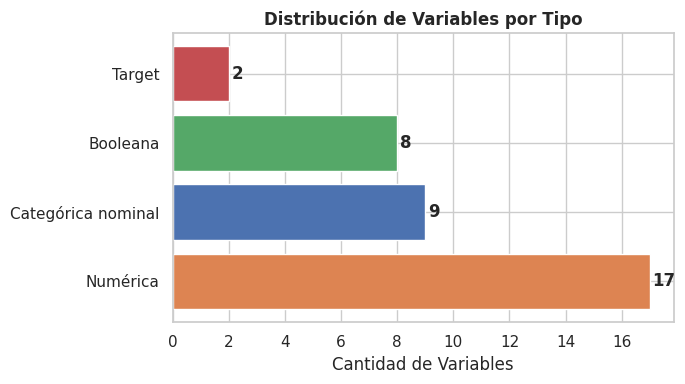

In [4]:
print("=" * 55)
print(f"  Filas       : {df.shape[0]}")
print(f"  Columnas    : {df.shape[1]}")
print(f"  Faltantes   : {df.isnull().sum().sum()}")
print(f"  Duplicados  : {df.duplicated().sum()}")
print("=" * 55)

# Resumen visual de tipos
tipo_df = pd.DataFrame({
    "Tipo": (["Categórica nominal"] * len(cat_nominal) +
             ["Booleana"]           * len(bool_vars)   +
             ["Numérica"]           * len(numeric_vars)+
             ["Target"]             * 2),
    "Variable": cat_nominal + bool_vars + numeric_vars + ["abandona","promedio_final"]
})
conteo = tipo_df["Tipo"].value_counts().reset_index()
conteo.columns = ["Tipo", "Cantidad"]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#DD8452","#4C72B0","#55A868","#C44E52"]
ax.barh(conteo["Tipo"], conteo["Cantidad"], color=colors, edgecolor="white")
for i, v in enumerate(conteo["Cantidad"]):
    ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
ax.set_title("Distribución de Variables por Tipo", fontweight="bold")
ax.set_xlabel("Cantidad de Variables")
plt.tight_layout()
plt.show()


---
## Sección 2 — Variables Categóricas Nominales

### 2.1 Frecuencia de Categorías (barplot)

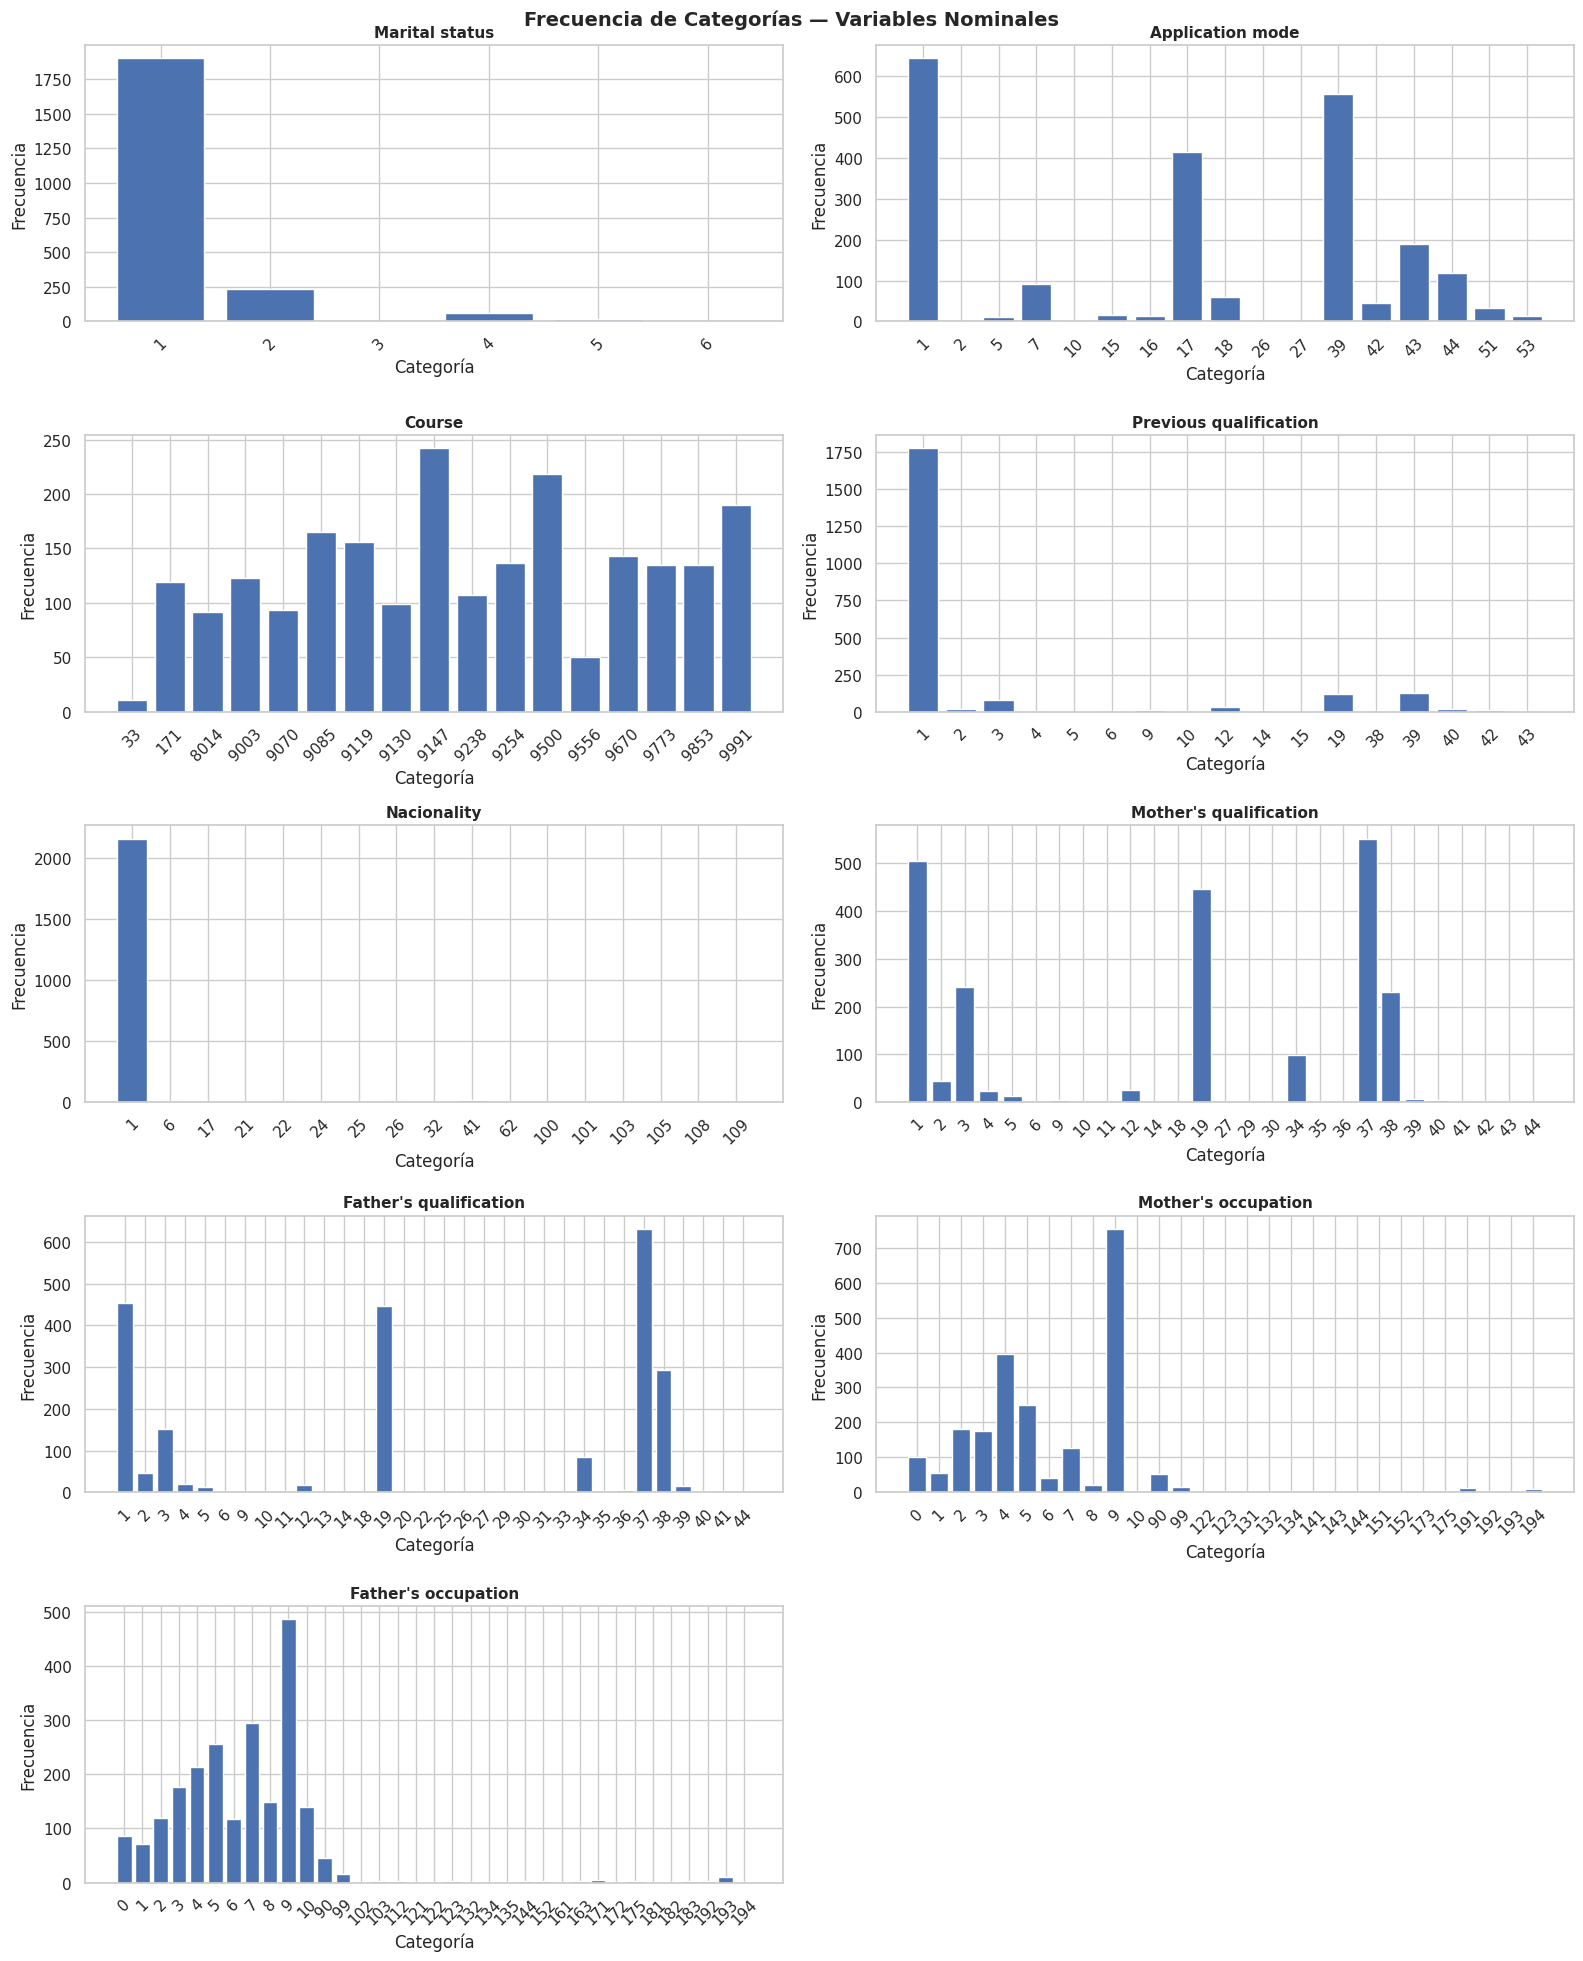

In [5]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Frecuencia de Categorías — Variables Nominales",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Tasa de Abandono por Categoría

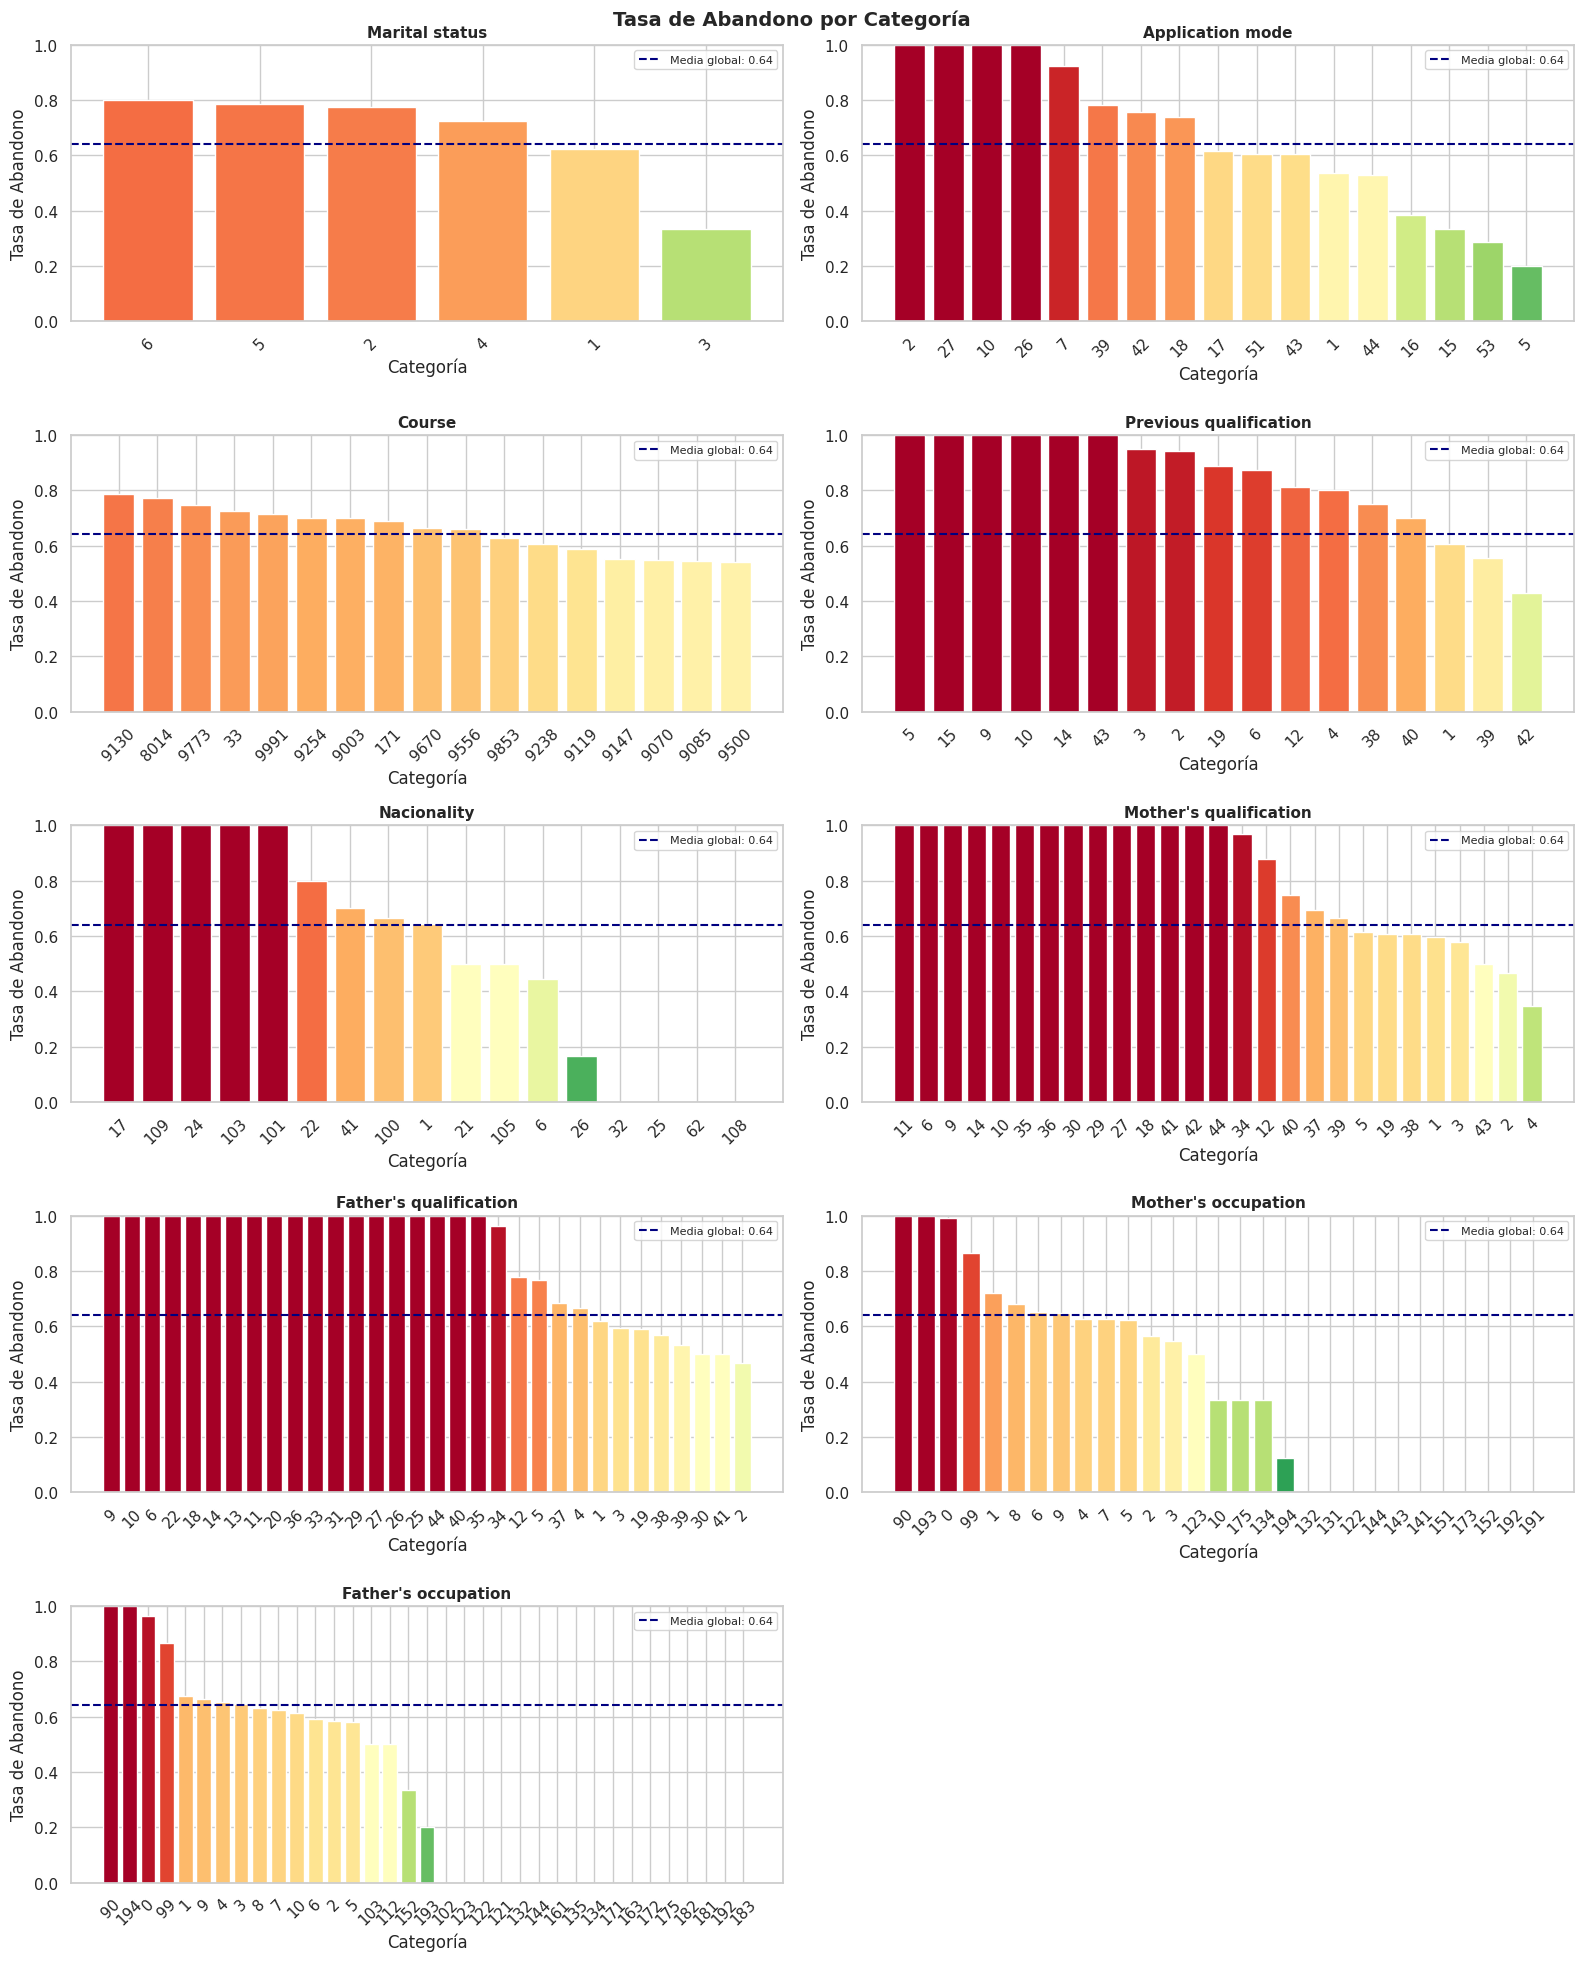

In [6]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    tasa = df.groupby(col)["abandona"].mean().sort_values(ascending=False)
    bars = axes[i].bar(tasa.index.astype(str), tasa.values,
                       color=plt.cm.RdYlGn_r(tasa.values), edgecolor="white")
    axes[i].axhline(df["abandona"].mean(), color="navy",
                    linestyle="--", linewidth=1.5, label=f'Media global: {df["abandona"].mean():.2f}')
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Categoría",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.3 Distribución de `promedio_final` por Categoría

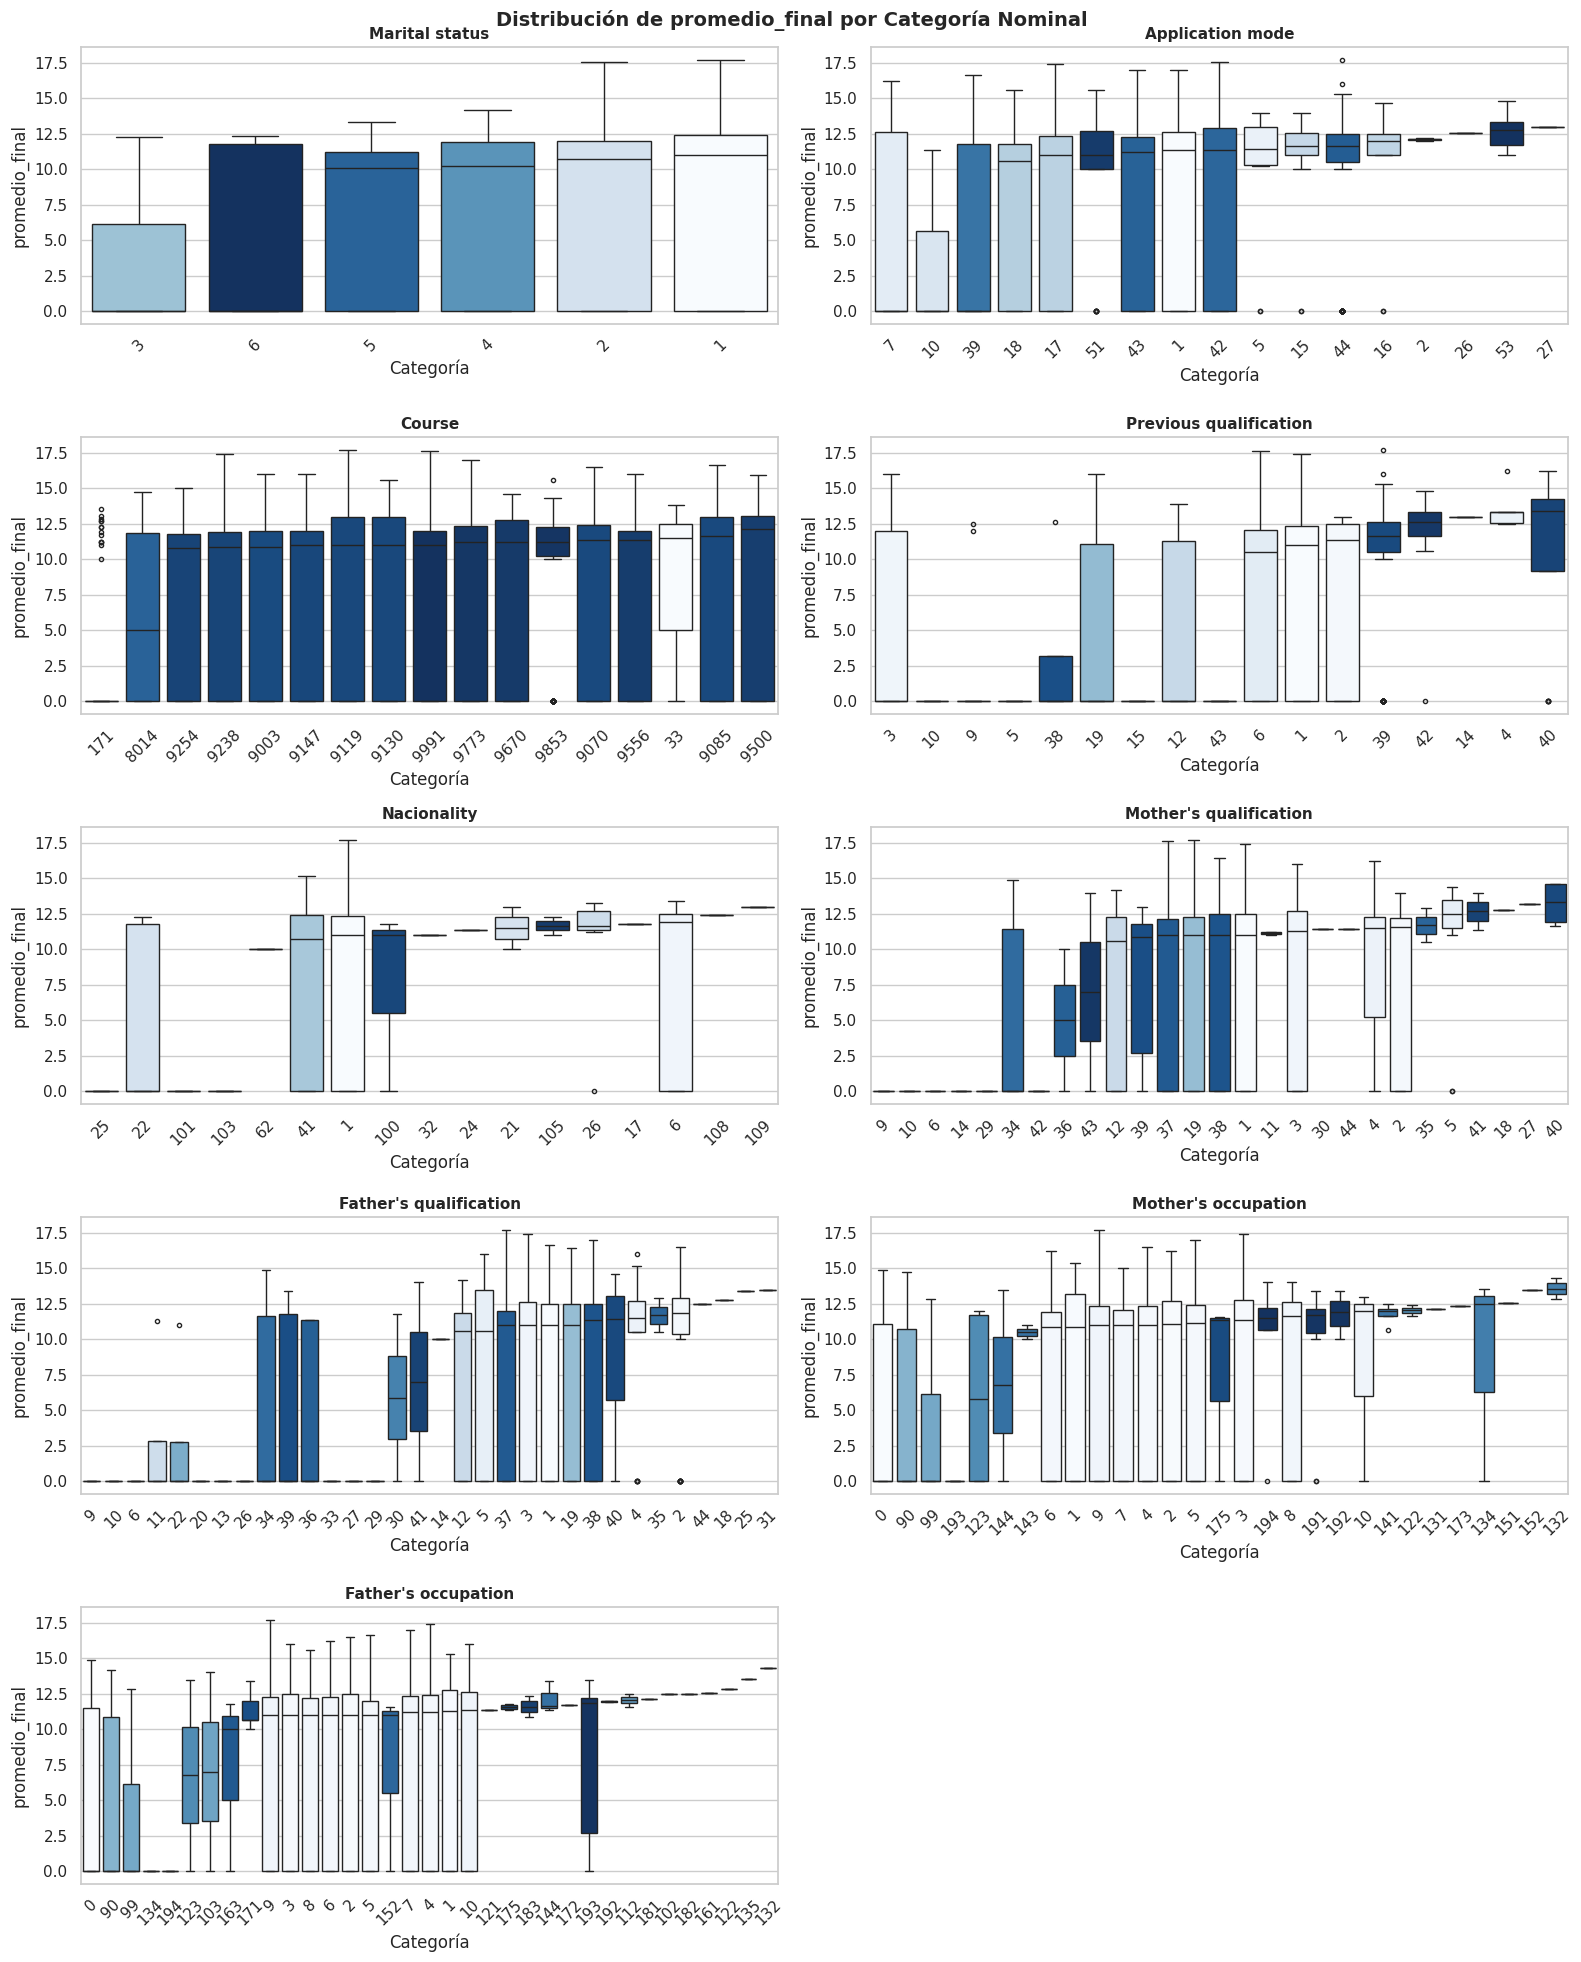

In [23]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    order = df.groupby(col)["promedio_final"].median().sort_values().index
    sns.boxplot(
        data=df, x=col, y="promedio_final",
        order=order, hue=col, legend=False, ax=axes[i],
        palette="Blues", flierprops={"marker":"o","markersize":3}
    )
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("promedio_final")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de promedio_final por Categoría Nominal",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.4 Tabla de Contingencia con `abandona`

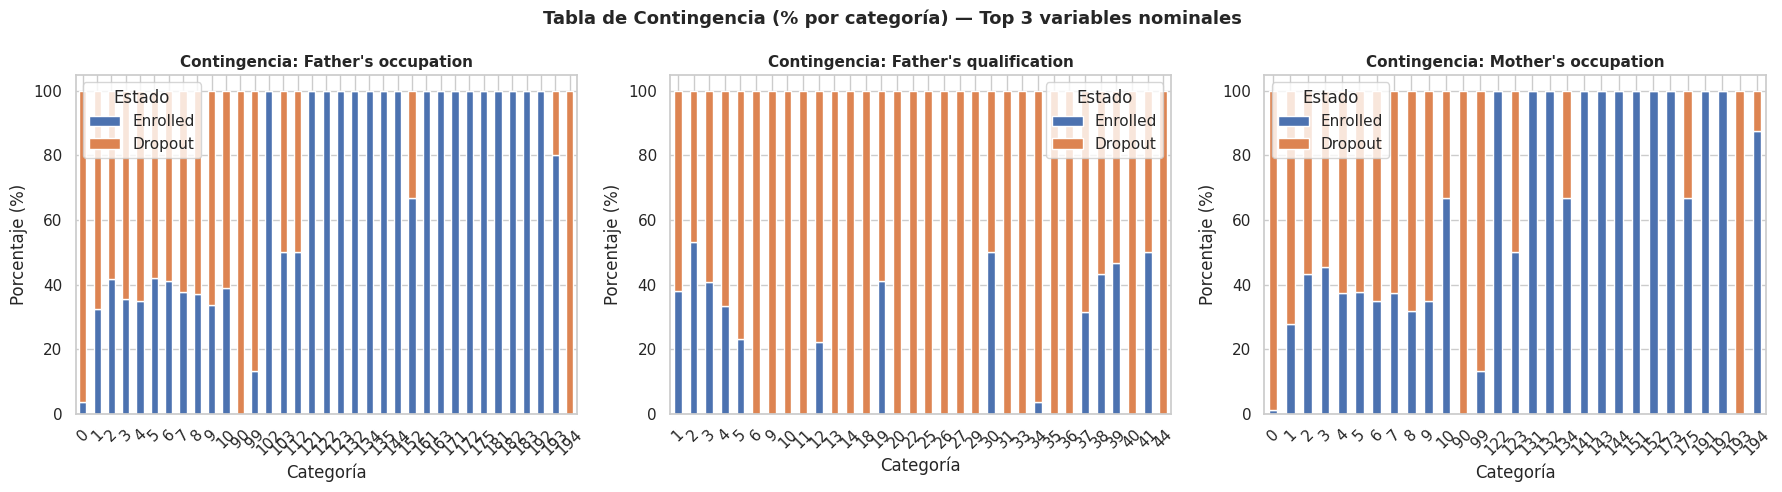


Test Chi-cuadrado (asociación con abandona):
  Variable                                chi2     p-value  Significativa
  -----------------------------------------------------------------
  Marital status                          25.8      0.0001  ✅ Sí
  Application mode                       155.7      0.0000  ✅ Sí
  Course                                  63.2      0.0000  ✅ Sí
  Previous qualification                 103.8      0.0000  ✅ Sí
  Nacionality                             18.6      0.2907  ❌ No
  Mother's qualification                 101.0      0.0000  ✅ Sí
  Father's qualification                  87.4      0.0000  ✅ Sí
  Mother's occupation                    166.2      0.0000  ✅ Sí
  Father's occupation                    140.0      0.0000  ✅ Sí


In [8]:
# Mostramos las 3 variables con más categorías para no saturar
top_cat_vars = sorted(cat_nominal, key=lambda c: df[c].nunique(), reverse=True)[:3]

fig, axes = plt.subplots(1, len(top_cat_vars), figsize=(18, 5))

for i, col in enumerate(top_cat_vars):
    ct = pd.crosstab(df[col], df["abandona"], normalize="index") * 100
    ct.columns = ["Enrolled", "Dropout"]
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0","#DD8452"],
            edgecolor="white", stacked=True)
    axes[i].set_title(f"Contingencia: {col}", fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Porcentaje (%)")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title="Estado")
    axes[i].set_ylim(0, 105)

plt.suptitle("Tabla de Contingencia (% por categoría) — Top 3 variables nominales",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Chi-cuadrado para todas las nominales
from scipy.stats import chi2_contingency
print("\nTest Chi-cuadrado (asociación con abandona):")
print(f"  {"Variable":<35} {"chi2":>8}  {"p-value":>10}  Significativa")
print("  " + "-"*65)
for col in cat_nominal:
    ct = pd.crosstab(df[col], df["abandona"])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "✅ Sí" if p < 0.05 else "❌ No"
    print(f"  {col:<35} {chi2:>8.1f}  {p:>10.4f}  {sig}")


---
## Sección 3 — Variables Booleanas

### 3.1 Tasa de Abandono por Grupo (0 vs 1)

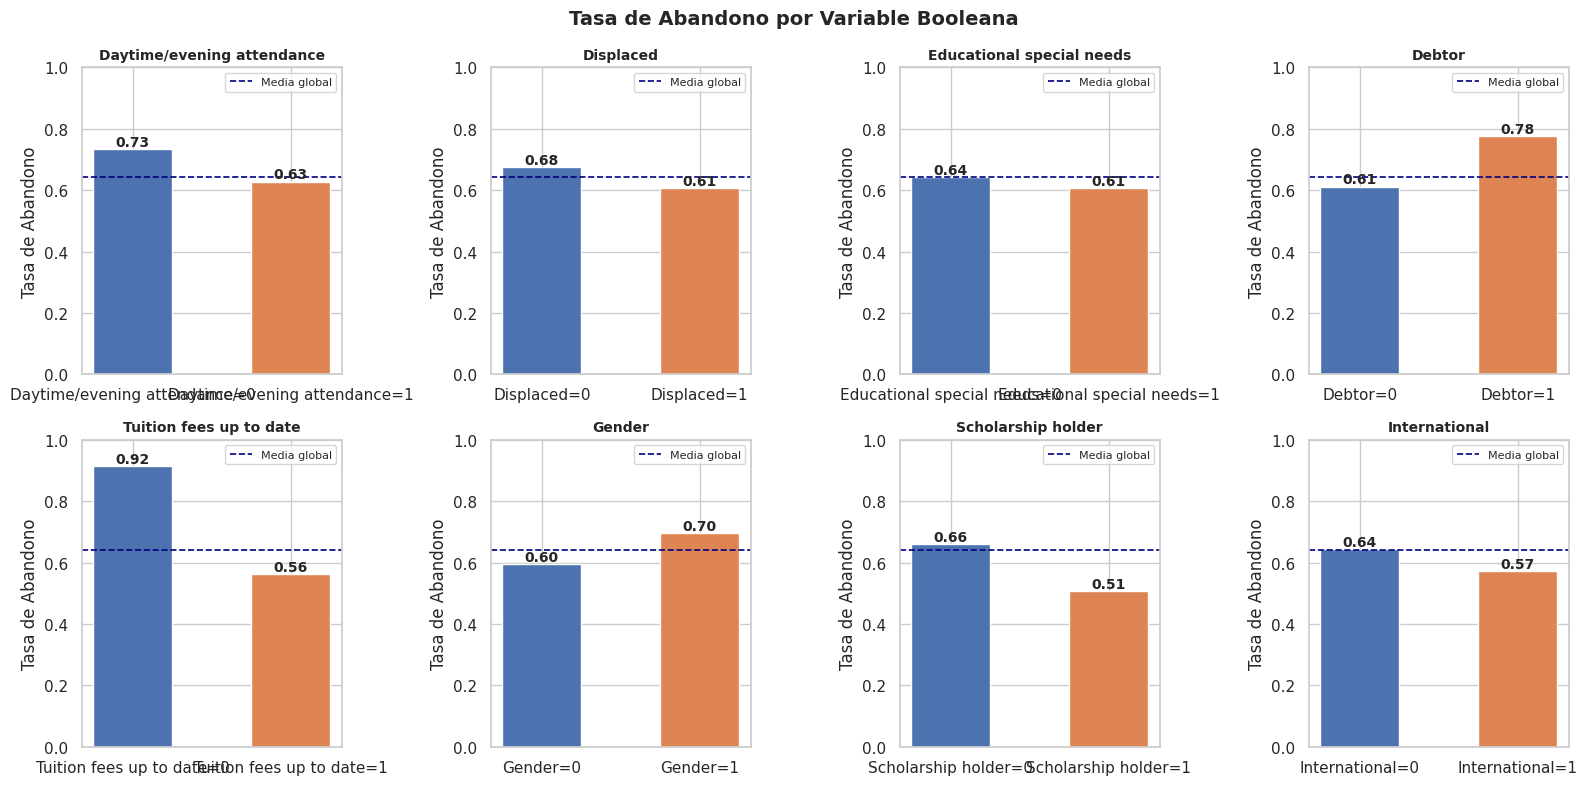

In [9]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(bool_vars):
    tasa = df.groupby(col)["abandona"].mean()
    labels = [f"{col}=0", f"{col}=1"]
    bars = axes[i].bar(labels, tasa.values,
                       color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, tasa.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f"{val:.2f}", ha="center", fontweight="bold", fontsize=10)
    axes[i].axhline(df["abandona"].mean(), color="navy",
                    linestyle="--", linewidth=1.2, label="Media global")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Variable Booleana",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.2 Comparación de `promedio_final` entre Grupos

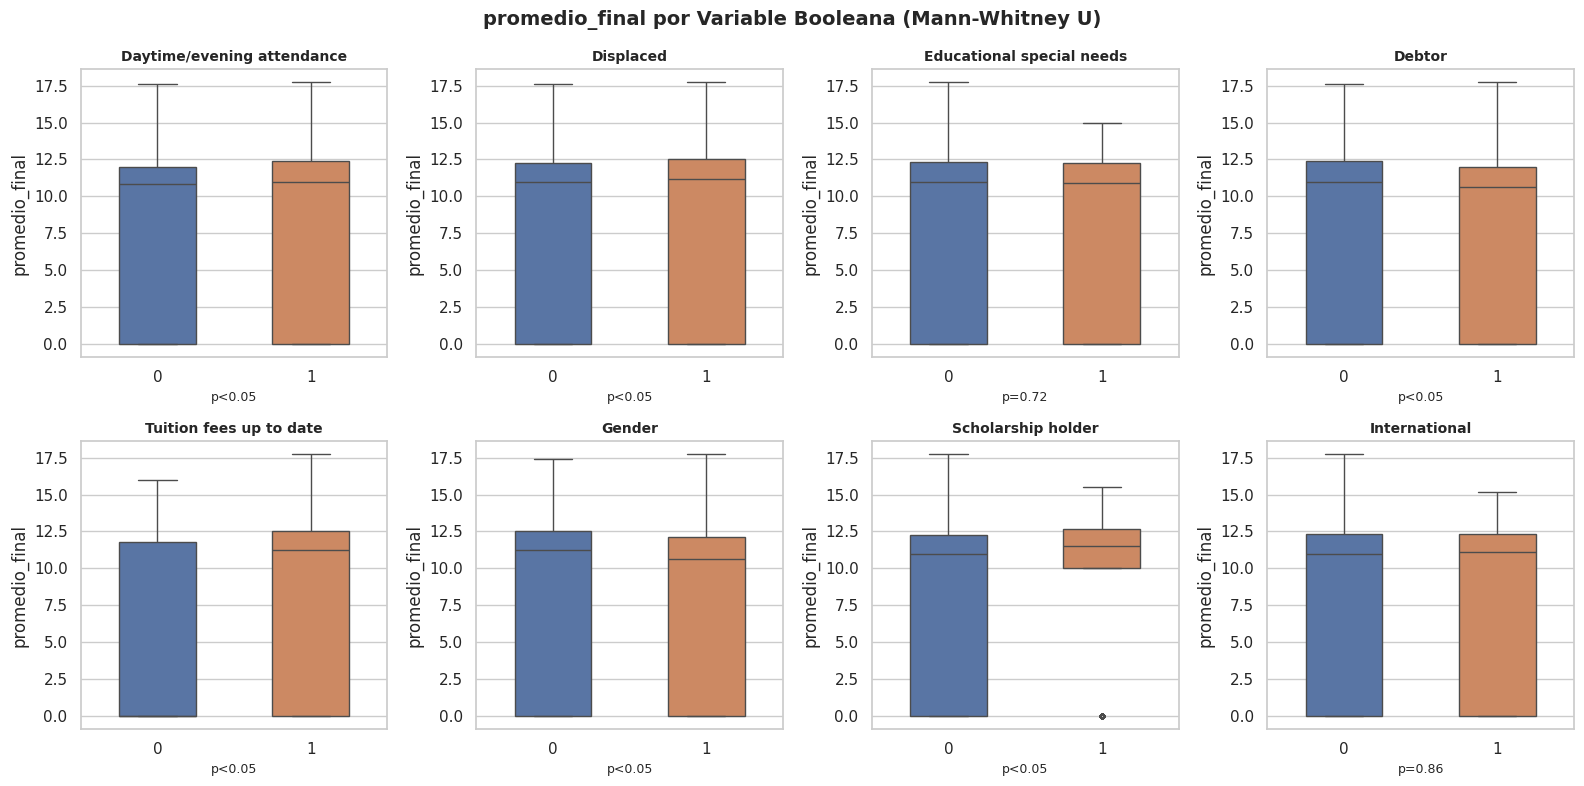

In [27]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

from scipy.stats import mannwhitneyu

palette_bin = {0: "#4C72B0", 1: "#DD8452", "0": "#4C72B0", "1": "#DD8452"}

for i, col in enumerate(bool_vars):
    sns.boxplot(
        data=df, x=col, y="promedio_final", hue=col,
        palette=palette_bin, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":3}
    )
    # Test Mann-Whitney U
    g0 = df[df[col]==0]["promedio_final"]
    g1 = df[df[col]==1]["promedio_final"]
    if len(g0) > 0 and len(g1) > 0:
        _, p = mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "p<0.05" if p < 0.05 else f"p={p:.2f}"
        axes[i].set_xlabel(sig, fontsize=9)
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_ylabel("promedio_final")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0", "1"])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("promedio_final por Variable Booleana (Mann-Whitney U)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Sección 4 — Variables Numéricas / Continuas

### 4.1 Estadísticas Descriptivas por Clase

In [11]:
desc_dropout  = df[df["abandona"]==1][numeric_vars].describe().T
desc_enrolled = df[df["abandona"]==0][numeric_vars].describe().T

desc_combined = desc_dropout[["mean","std","50%"]].copy()
desc_combined.columns = ["mean_dropout","std_dropout","median_dropout"]
desc_combined["mean_enrolled"]   = desc_enrolled["mean"]
desc_combined["std_enrolled"]    = desc_enrolled["std"]
desc_combined["median_enrolled"] = desc_enrolled["50%"]
desc_combined["diff_means"]      = (desc_combined["mean_dropout"]
                                    - desc_combined["mean_enrolled"]).round(3)

print("Estadísticas descriptivas por clase (Dropout vs Enrolled):")
display(desc_combined.round(3).style.background_gradient(
    cmap="RdYlGn_r", subset=["diff_means"]))


Estadísticas descriptivas por clase (Dropout vs Enrolled):


,mean_dropout,std_dropout,median_dropout,mean_enrolled,std_enrolled,median_enrolled,diff_means
Application order,1.593000,1.216000,1.000000,1.626000,1.214000,1.000000,-0.033000
Previous qualification (grade),131.114000,12.873000,133.100000,131.208000,12.872000,130.000000,-0.094000
Admission grade,124.961000,15.125000,123.600000,125.534000,13.793000,124.100000,-0.573000
Age at enrollment,26.069000,8.704000,23.000000,22.369000,6.303000,20.000000,3.700000
Curricular units 1st sem (credited),0.609000,2.105000,0.000000,0.508000,1.716000,0.000000,0.102000
Curricular units 1st sem (enrolled),5.821000,2.326000,6.000000,5.965000,1.988000,6.000000,-0.143000
Curricular units 1st sem (evaluations),7.752000,4.922000,8.000000,9.341000,3.463000,9.000000,-1.590000
Curricular units 1st sem (approved),2.552000,2.858000,2.000000,4.319000,2.289000,5.000000,-1.767000
Curricular units 1st sem (without evaluations),0.192000,0.795000,0.000000,0.178000,0.741000,0.000000,0.015000
Curricular units 2nd sem (credited),0.450000,1.680000,0.000000,0.359000,1.329000,0.000000,0.091000


### 4.2 Histogramas por Clase (Dropout vs Enrolled)

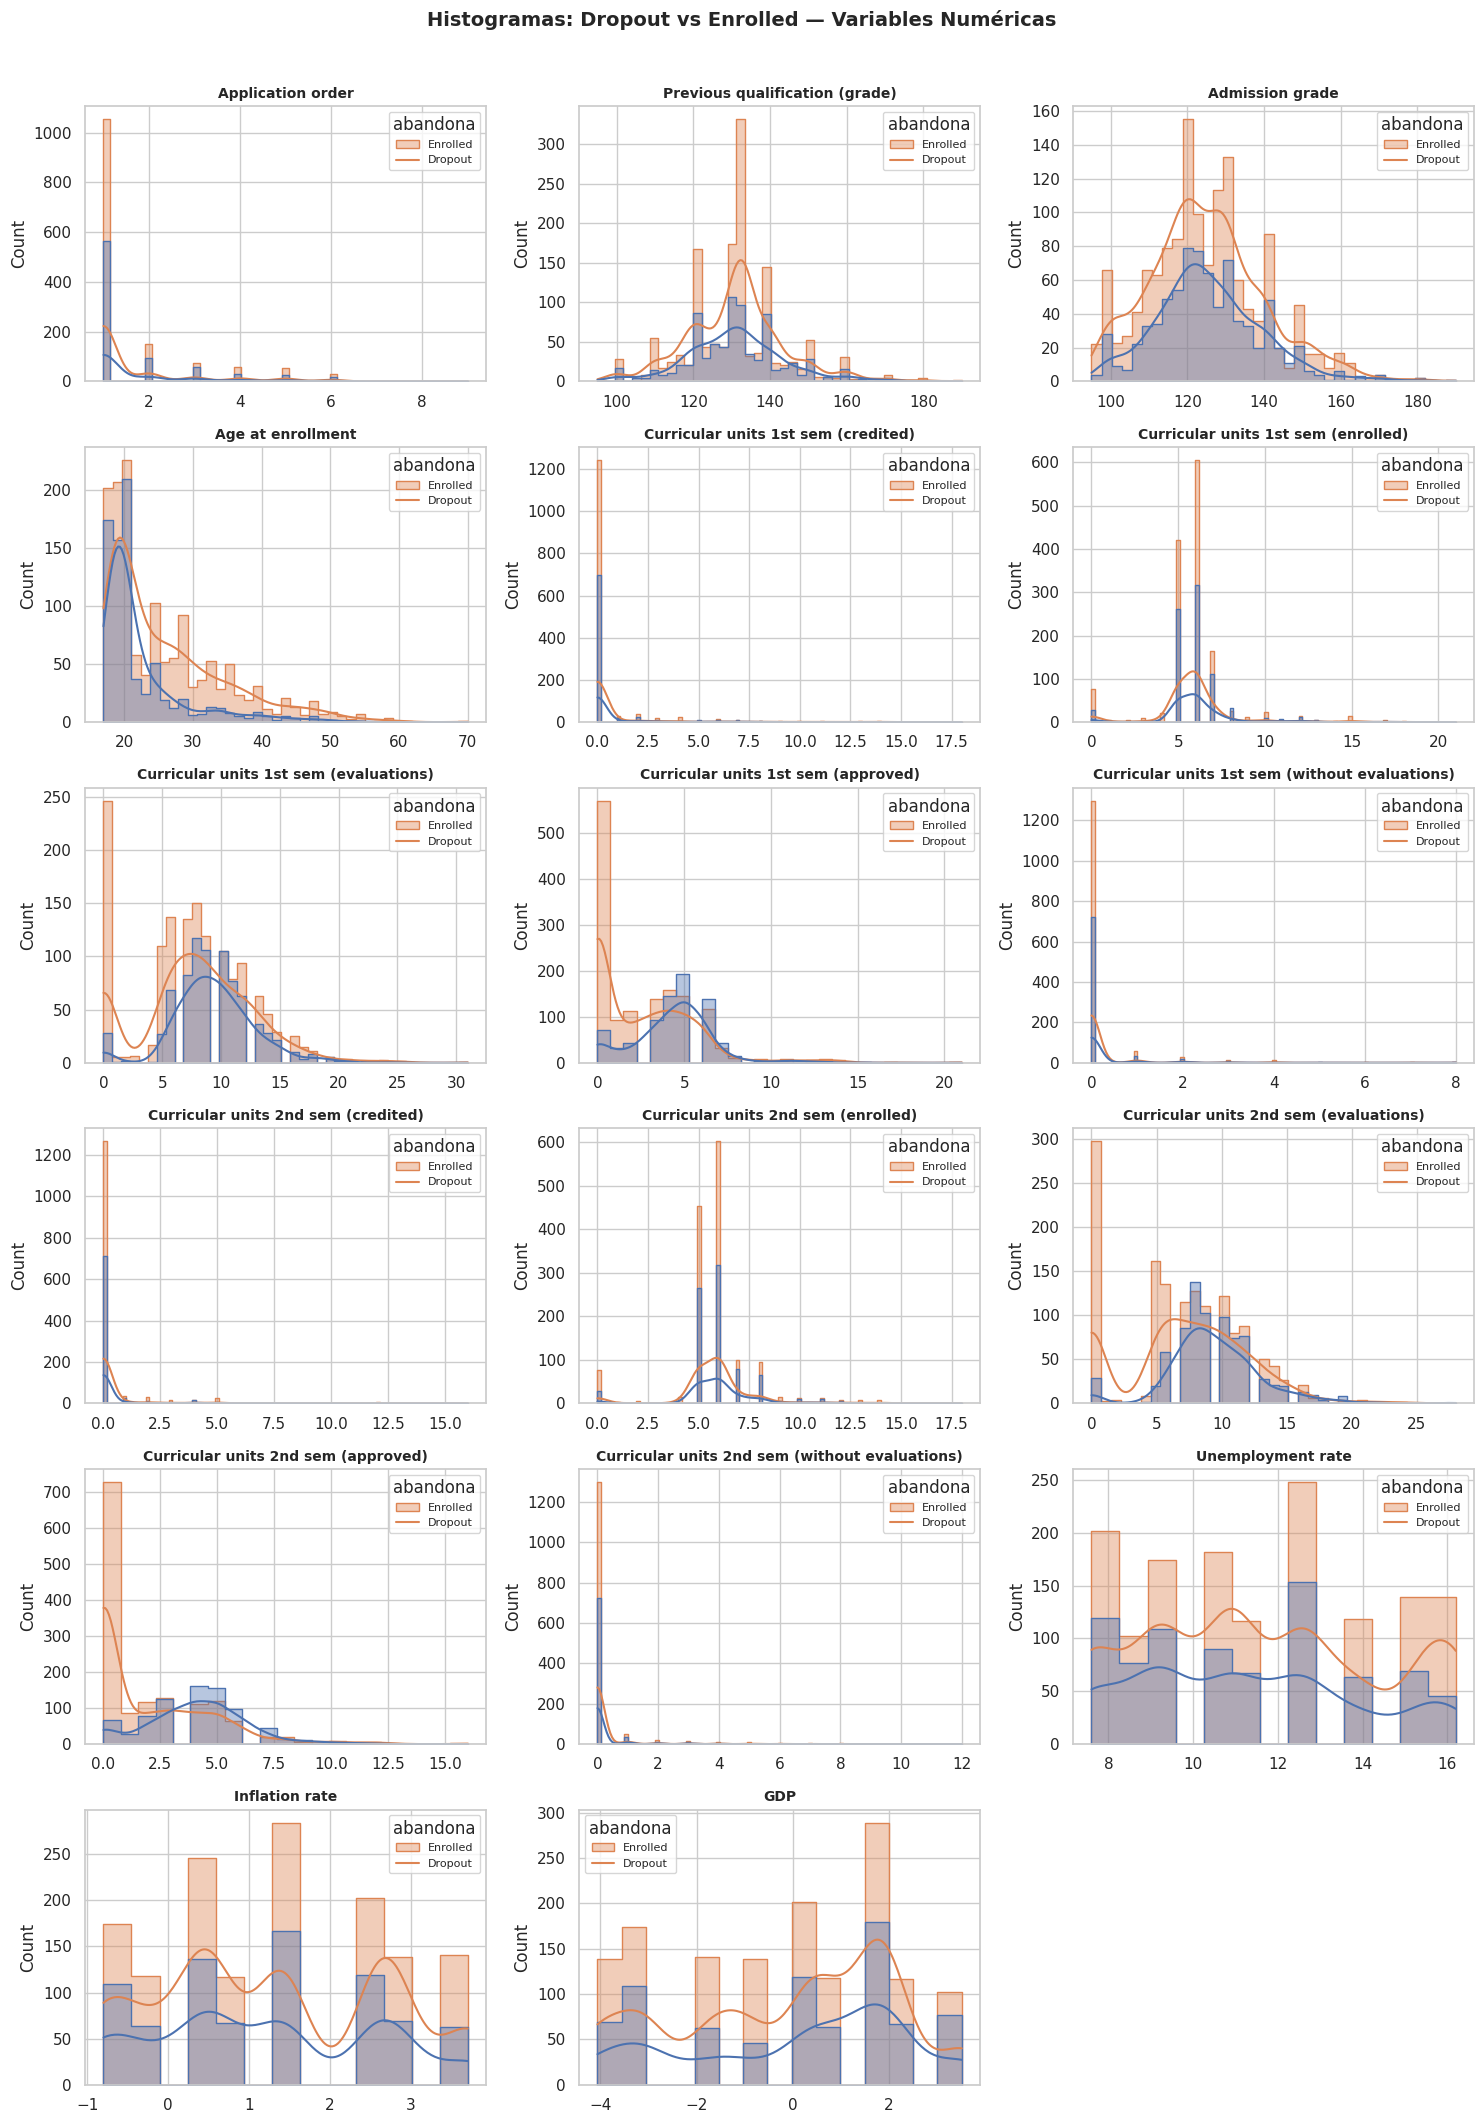

In [12]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.histplot(
        data=df, x=col, hue="abandona",
        kde=True, element="step", alpha=0.4,
        palette={0:"#4C72B0", 1:"#DD8452"},
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(title="abandona", labels=["Enrolled","Dropout"], fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogramas: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Boxplots por Clase

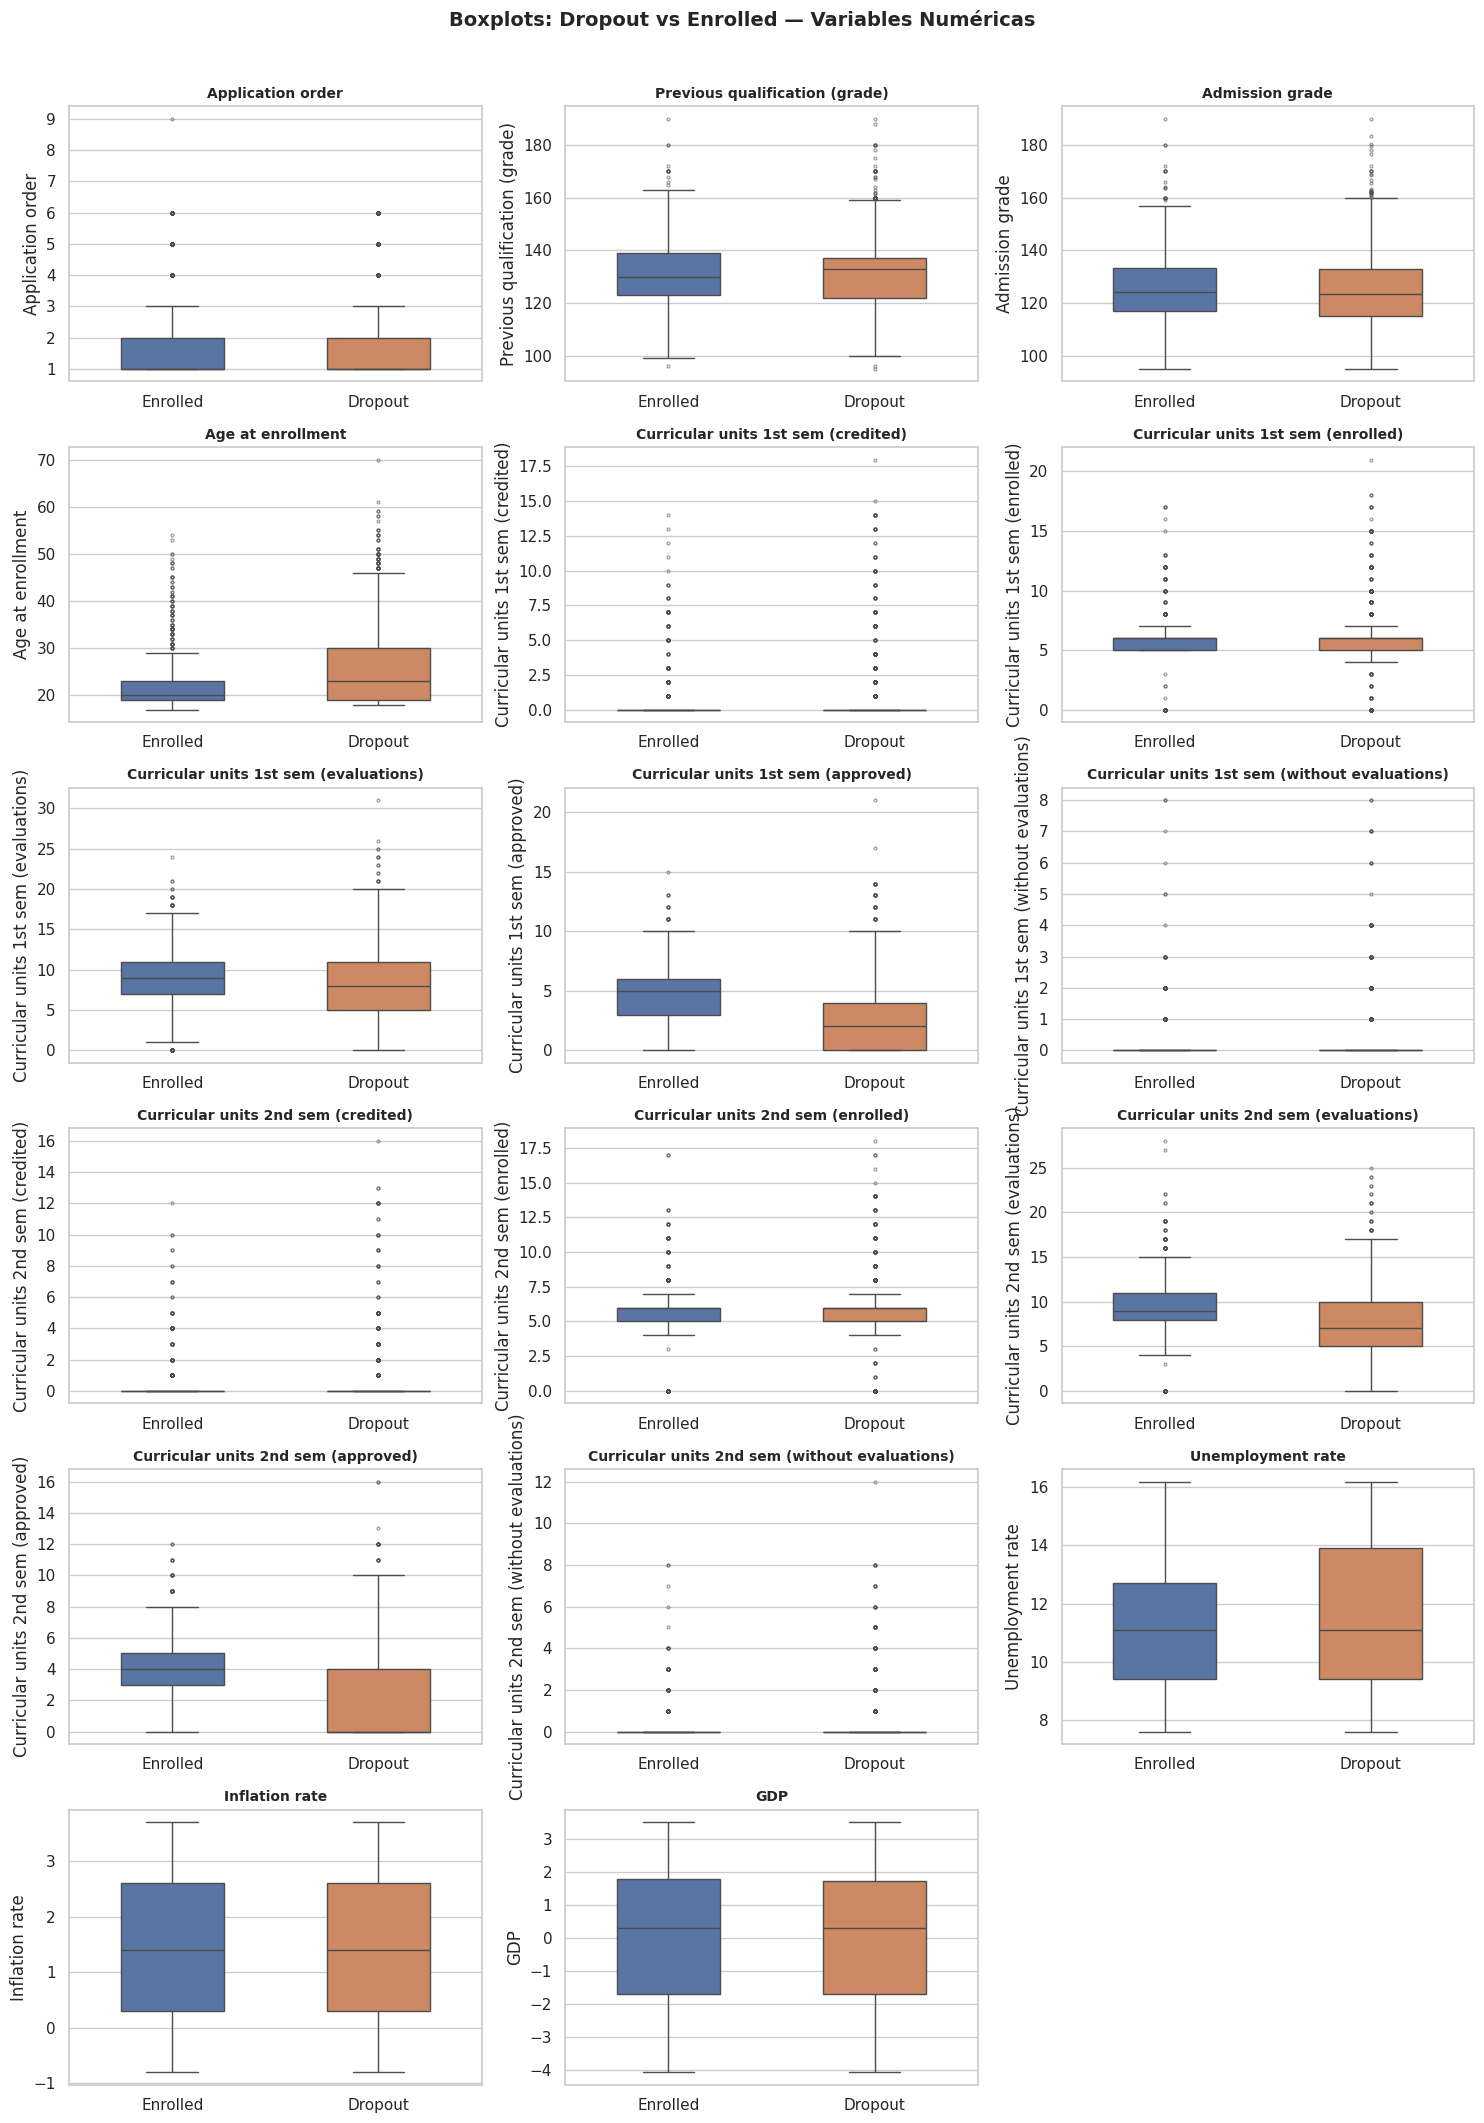

In [30]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

palette_bin = {0: "#4C72B0", 1: "#DD8452", "0": "#4C72B0", "1": "#DD8452"}

for i, col in enumerate(numeric_vars):
    sns.boxplot(
        data=df, x="abandona", y=col, hue="abandona",
        palette=palette_bin, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":2,"alpha":0.5}
    )
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Enrolled", "Dropout"])

    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 4.4 Matriz de Correlación (variables numéricas + targets)

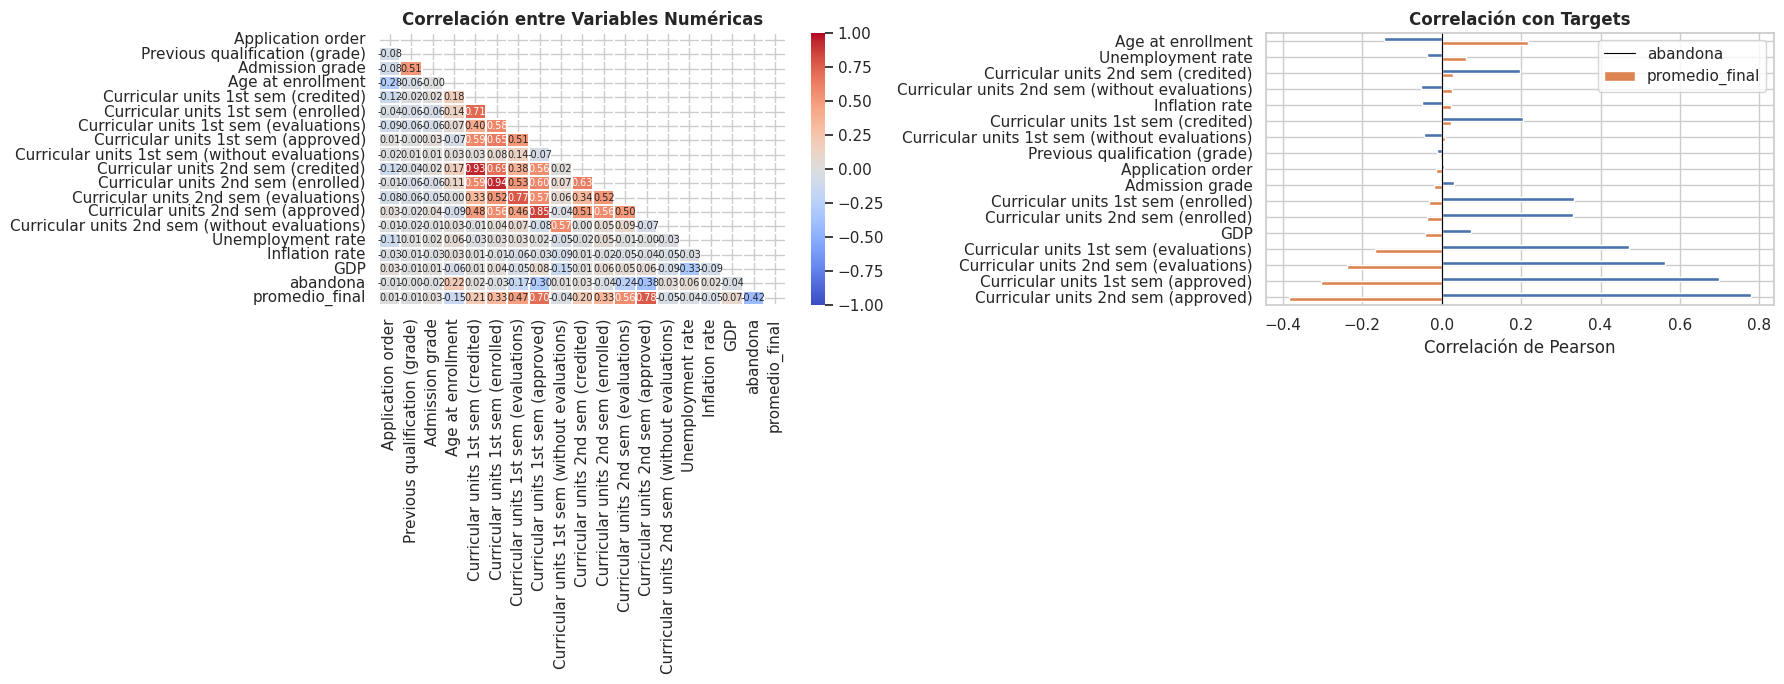

In [14]:
corr_cols = numeric_vars + ["abandona", "promedio_final"]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.3,
    ax=axes[0], vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
axes[0].set_title("Correlación entre Variables Numéricas", fontweight="bold")

# Correlación con targets (barras)
corr_targets = corr_matrix[["abandona","promedio_final"]]\
                           .drop(["abandona","promedio_final"])\
                           .sort_values("abandona")
corr_targets.plot(kind="barh", ax=axes[1],
                  color=["#DD8452","#4C72B0"], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con Targets", fontweight="bold")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].legend(["abandona","promedio_final"])

plt.tight_layout()
plt.show()


---
## Sección 5 — Variables Target

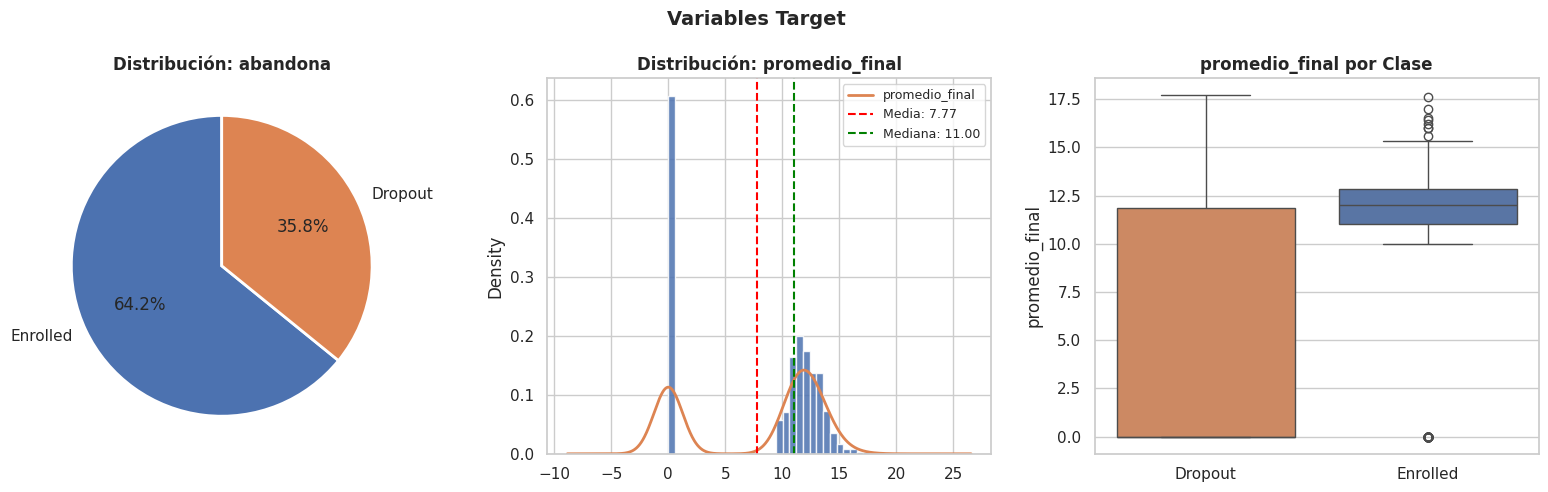


Estadísticas por clase:
           count   mean   std  min   25%   50%    75%    max
abandona                                                    
Enrolled   794.0  11.12  3.60  0.0  11.0  12.0  12.82  17.60
Dropout   1421.0   5.90  6.12  0.0   0.0   0.0  11.83  17.71


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target clasificación: distribución
counts = df["abandona"].value_counts()
axes[0].pie(
    counts.values,
    labels=["Enrolled","Dropout"],
    autopct="%1.1f%%",
    colors=["#4C72B0","#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
axes[0].set_title("Distribución: abandona", fontweight="bold")

# Target regresión: histograma
axes[1].hist(df["promedio_final"], bins=30,
             color="#4C72B0", edgecolor="white", alpha=0.85, density=True)
df["promedio_final"].plot(kind="kde", ax=axes[1], color="#DD8452", linewidth=2)
axes[1].axvline(df["promedio_final"].mean(), color="red", linestyle="--",
                label=f'Media: {df["promedio_final"].mean():.2f}')
axes[1].axvline(df["promedio_final"].median(), color="green", linestyle="--",
                label=f'Mediana: {df["promedio_final"].median():.2f}')
axes[1].set_title("Distribución: promedio_final", fontweight="bold")
axes[1].legend(fontsize=9)

# promedio_final por clase
df_box = df[["promedio_final","abandona"]].copy()
df_box["Clase"] = df_box["abandona"].map({0:"Enrolled",1:"Dropout"})
sns.boxplot(data=df_box, x="Clase", y="promedio_final", hue="Clase",
            palette={"Enrolled":"#4C72B0","Dropout":"#DD8452"},
            legend=False, ax=axes[2])
axes[2].set_title("promedio_final por Clase", fontweight="bold")
axes[2].set_xlabel("")

plt.suptitle("Variables Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nEstadísticas por clase:")
print(df.groupby("abandona")["promedio_final"]
        .describe().round(2)
        .rename(index={0:"Enrolled",1:"Dropout"}))


---
## Resumen del EDA

SOme text

---
# **Preprocesamiento**

Pasos:
1. `ColumnTransformer`: `OneHotEncoder` + `StandardScaler` + passthrough
2. División **Train 64% / Validation 16% / Test 20%**
3. Ajustar el preprocessor **solo con train** (evita data leakage)
4. Seleccionar Top 8 features por correlación (calculada sobre train)


### Paso 1 — ColumnTransformer (OHE + Scaler + Passthrough)

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

preprocessor = ColumnTransformer(
    transformers=[
        ("ohe",
         OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
         cat_nominal),
        ("scaler",
         StandardScaler(),
         numeric_vars),
        ("bool",
         "passthrough",
         bool_vars),
    ],
    remainder="drop"
)
print("✅ ColumnTransformer definido")


✅ ColumnTransformer definido


### Paso 2 — División Train / Validation / Test

> **Train 64%** — entrenar  |  **Validation 16%** — elegir `k`  |  **Test 20%** — evaluación final


In [19]:
SEED = 42

X_raw = df[all_feature_cols]
y_clf = df["abandona"].values
y_reg = df["promedio_final"].values

# 1) Apartar Test (20%)
X_temp, X_test_raw, y_clf_temp, y_clf_test = train_test_split(
    X_raw, y_clf, test_size=0.20, random_state=SEED, stratify=y_clf)
_, _, y_reg_temp, y_reg_test = train_test_split(
    X_raw, y_reg, test_size=0.20, random_state=SEED)

# 2) Apartar Validation (20% del 80% restante = 16% total)
X_train_raw, X_val_raw, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_clf_temp, test_size=0.20, random_state=SEED, stratify=y_clf_temp)
_, _, y_reg_train, y_reg_val = train_test_split(
    X_temp, y_reg_temp, test_size=0.20, random_state=SEED)

total = len(df)
print("División completada:")
print(f"  Train      : {len(X_train_raw):>4}  ({len(X_train_raw)/total*100:.0f}%)")
print(f"  Validation : {len(X_val_raw):>4}  ({len(X_val_raw)/total*100:.0f}%)")
print(f"  Test       : {len(X_test_raw):>4}  ({len(X_test_raw)/total*100:.0f}%)")
print("\nBalance (abandona):")
for name, y in [("Train", y_clf_train), ("Val", y_clf_val), ("Test", y_clf_test)]:
    d = y.sum(); e = (y==0).sum()
    print(f"  {name:<10}: Dropout {d:>3} ({d/len(y)*100:.1f}%)  Enrolled {e:>3} ({e/len(y)*100:.1f}%)")


División completada:
  Train      : 1417  (64%)
  Validation :  355  (16%)
  Test       :  443  (20%)

Balance (abandona):
  Train     : Dropout 909 (64.1%)  Enrolled 508 (35.9%)
  Val       : Dropout 228 (64.2%)  Enrolled 127 (35.8%)
  Test      : Dropout 284 (64.1%)  Enrolled 159 (35.9%)


### Paso 3 — Fit (solo train) + Transform (train / val / test)

In [31]:
preprocessor.fit(X_train_raw)

X_train = preprocessor.transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

ohe_cols = preprocessor.named_transformers_["ohe"]\
                        .get_feature_names_out(cat_nominal).tolist()
all_transformed_cols = ohe_cols + numeric_vars + bool_vars
df_train_t = pd.DataFrame(X_train, columns=all_transformed_cols)

print(f"✅ Features originales   : {len(all_feature_cols)}")
print(f"   Features transformadas: {X_train.shape[1]}")
print(f"   (OHE generó {len(ohe_cols)} columnas dummy)")


✅ Features originales   : 34
   Features transformadas: 195
   (OHE generó 170 columnas dummy)


/home/luencaro/Programing/My Repositories/College/Machine Learning/knn-student-retention-analysis/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/luencaro/Programing/My Repositories/College/Machine Learning/knn-student-retention-analysis/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Paso 4 — Top 8 Features por Correlación (calculada sobre train)

In [21]:
TOP_N = 8

df_corr = df_train_t.copy()
df_corr["abandona"]       = y_clf_train
df_corr["promedio_final"] = y_reg_train
corr_all = df_corr.corr()

top_clf = (corr_all["abandona"]
           .drop(["abandona","promedio_final"])
           .abs().sort_values(ascending=False).head(TOP_N))
top_reg = (corr_all["promedio_final"]
           .drop(["abandona","promedio_final"])
           .abs().sort_values(ascending=False).head(TOP_N))

features_clf = top_clf.index.tolist()
features_reg = top_reg.index.tolist()
idx_clf = [all_transformed_cols.index(f) for f in features_clf]
idx_reg = [all_transformed_cols.index(f) for f in features_reg]

X_clf_train = X_train[:, idx_clf];  X_clf_val = X_val[:, idx_clf];  X_clf_test = X_test[:, idx_clf]
X_reg_train = X_train[:, idx_reg];  X_reg_val = X_val[:, idx_reg];  X_reg_test = X_test[:, idx_reg]

print(f"Top {TOP_N} — CLASIFICACIÓN:"); [print(f"  {f:<45} |r|={v:.3f}") for f,v in top_clf.items()]
print(f"\nTop {TOP_N} — REGRESIÓN:");    [print(f"  {f:<45} |r|={v:.3f}") for f,v in top_reg.items()]


Top 8 — CLASIFICACIÓN:
  Curricular units 2nd sem (approved)           |r|=0.397
  Tuition fees up to date                       |r|=0.321
  Curricular units 1st sem (approved)           |r|=0.306
  Curricular units 2nd sem (evaluations)        |r|=0.224
  Age at enrollment                             |r|=0.224
  Curricular units 1st sem (evaluations)        |r|=0.176
  Application mode_39                           |r|=0.165
  Debtor                                        |r|=0.148

Top 8 — REGRESIÓN:
  Mother's qualification_37                     |r|=0.064
  Father's qualification_4                      |r|=0.061
  Application mode_5                            |r|=0.061
  Mother's qualification_19                     |r|=0.059
  Course_9670                                   |r|=0.059
  Father's qualification_37                     |r|=0.056
  Father's occupation_10                        |r|=0.054
  Curricular units 2nd sem (enrolled)           |r|=0.053


[None, None, None, None, None, None, None, None]

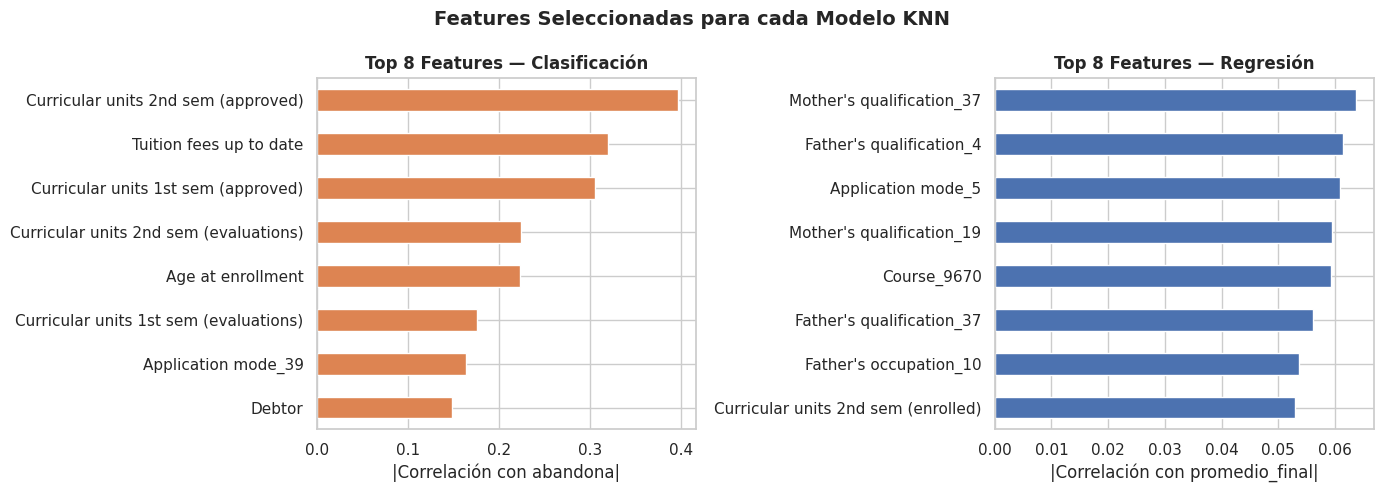

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_clf.sort_values().plot(kind="barh", ax=axes[0], color="#DD8452", edgecolor="white")
axes[0].set_title(f"Top {TOP_N} Features — Clasificación", fontweight="bold")
axes[0].set_xlabel("|Correlación con abandona|")
top_reg.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_title(f"Top {TOP_N} Features — Regresión", fontweight="bold")
axes[1].set_xlabel("|Correlación con promedio_final|")
plt.suptitle("Features Seleccionadas para cada Modelo KNN", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()